# 02b — Category Classification (Problem B)

Multi-label incident category classification using three tiers:
- **Tier 1 (Baseline):** TF-IDF + Logistic Regression
- **Tier 2 (Ablation):** Sentence-BERT + Logistic Regression
- **Tier 3 (Fusion):** Text Tower + Tabular → MLP per-label heads

In [1]:
import os
from pathlib import Path

# Find project root (contains pyproject.toml)
root = Path.cwd()
while not (root / "pyproject.toml").exists():
    root = root.parent
os.chdir(root)
print(f"Working directory: {root}")

Working directory: e:\OSFDA


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils.config import set_seeds, resolve_path, load_main_config
from src.data.loader import load_raw_data, parse_time_date
from src.data.target_engineering import apply_severity_rubric, apply_category_taxonomy
from src.features.temporal import create_temporal_split
from src.features.text import preprocess_narratives, combine_text_fields
from src.evaluation.multilabel_metrics import multilabel_report

set_seeds()
config = load_main_config()
print('Setup complete.')

Setup complete.


## 1. Load and Prepare Data

In [3]:
df = load_raw_data(config)
df = apply_severity_rubric(df)
df = parse_time_date(df)
df = create_temporal_split(df)
df, cat_matrix = apply_category_taxonomy(df)
df = preprocess_narratives(df)
df = combine_text_fields(df, output_col='combined_text')

label_names = sorted(cat_matrix.columns.tolist())
print(f'Dataset: {len(df)} rows, Labels: {label_names}')
display(cat_matrix.sum().rename('count').to_frame())

Loaded 38655 records from E:\OSFDA\data\raw\asrs_full.parquet
Dataset: 38655 rows, Labels: ['ATC_Communication', 'Airspace_Navigation', 'Environment', 'Equipment_System', 'Flight_Operations']


,count
ATC_Communication,6592
Airspace_Navigation,2282
Environment,8510
Equipment_System,16439
Flight_Operations,28648


In [4]:
# Per-split label distribution
tr_mask = df['split'] == 'train'
va_mask = df['split'] == 'val'
te_mask = df['split'] == 'test'

for sp in ['train', 'val', 'test']:
    mask = df['split'] == sp
    print(f'{sp}: {mask.sum()} rows')

train: 22854 rows
val: 2492 rows
test: 13309 rows


## 2. Tier 1 — TF-IDF Baseline

In [5]:
from src.models.category import build_tfidf_baseline, predict_tfidf

tier1_model = build_tfidf_baseline(
    df.loc[tr_mask, 'combined_text'], cat_matrix.loc[tr_mask],
    df.loc[va_mask, 'combined_text'], cat_matrix.loc[va_mask],
    label_names,
)
print('Thresholds:', tier1_model['thresholds'])

  [Baseline] Fitting TF-IDF vectorizer...


e:\OSFDA\.venv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Thresholds: {'ATC_Communication': 0.55, 'Airspace_Navigation': 0.9000000000000001, 'Environment': 0.6000000000000001, 'Equipment_System': 0.45, 'Flight_Operations': 0.55}


In [6]:
_, t1_preds = predict_tfidf(tier1_model, df.loc[te_mask, 'combined_text'])
t1_report = multilabel_report(cat_matrix.loc[te_mask].values, t1_preds, label_names)

print('=== Tier 1 (TF-IDF) Test Results ===')
print(f"  Macro-F1:   {t1_report['macro_f1']:.4f}")
print(f"  Micro-F1:   {t1_report['micro_f1']:.4f}")
print(f"  Hamming:    {t1_report['hamming_loss']:.4f}")
for label in label_names:
    f1 = t1_report['per_label'][label]['f1']
    print(f'  {label:<28} {f1:.3f}')

=== Tier 1 (TF-IDF) Test Results ===
  Macro-F1:   0.6262
  Micro-F1:   0.7601
  Hamming:    0.1587
  ATC_Communication            0.547
  Airspace_Navigation          0.371
  Environment                  0.489
  Equipment_System             0.824
  Flight_Operations            0.900


## 3. Tier 2 — SBERT Text Tower

In [7]:
from src.models.category import encode_texts, build_text_tower, predict_text_tower

emb_path = resolve_path('data/processed')
if (emb_path / 'emb_train.npy').exists():
    print('Loading cached SBERT embeddings...')
    emb_train = np.load(emb_path / 'emb_train.npy')
    emb_val   = np.load(emb_path / 'emb_val.npy')
    emb_test  = np.load(emb_path / 'emb_test.npy')
else:
    print('Encoding texts with SBERT (~15-30min on CPU)...')
    emb_train = encode_texts(df.loc[tr_mask, 'combined_text'], batch_size=128)
    emb_val   = encode_texts(df.loc[va_mask, 'combined_text'], batch_size=128)
    emb_test  = encode_texts(df.loc[te_mask, 'combined_text'], batch_size=128)
    np.save(emb_path / 'emb_train.npy', emb_train)
    np.save(emb_path / 'emb_val.npy',   emb_val)
    np.save(emb_path / 'emb_test.npy',  emb_test)
    print('Embeddings saved.')
print(f'Embedding dim: {emb_train.shape[1]}')

Loading cached SBERT embeddings...
Embedding dim: 384


In [8]:
tier2_model = build_text_tower(
    emb_train, cat_matrix.loc[tr_mask],
    emb_val,   cat_matrix.loc[va_mask],
    label_names,
)
_, t2_preds = predict_text_tower(tier2_model, emb_test)
t2_report = multilabel_report(cat_matrix.loc[te_mask].values, t2_preds, label_names)

print('=== Tier 2 (SBERT) Test Results ===')
print(f"  Macro-F1:   {t2_report['macro_f1']:.4f}")
print(f"  Micro-F1:   {t2_report['micro_f1']:.4f}")
for label in label_names:
    f1 = t2_report['per_label'][label]['f1']
    print(f'  {label:<28} {f1:.3f}')

=== Tier 2 (SBERT) Test Results ===
  Macro-F1:   0.6042
  Micro-F1:   0.7372
  ATC_Communication            0.503
  Airspace_Navigation          0.377
  Environment                  0.477
  Equipment_System             0.787
  Flight_Operations            0.877


## 4. Tier Comparison

,macro_f1,micro_f1,hamming_loss,subset_accuracy
TF-IDF Baseline,0.6262,0.7601,0.1587,0.4229
SBERT Text Tower,0.6042,0.7372,0.1753,0.3726


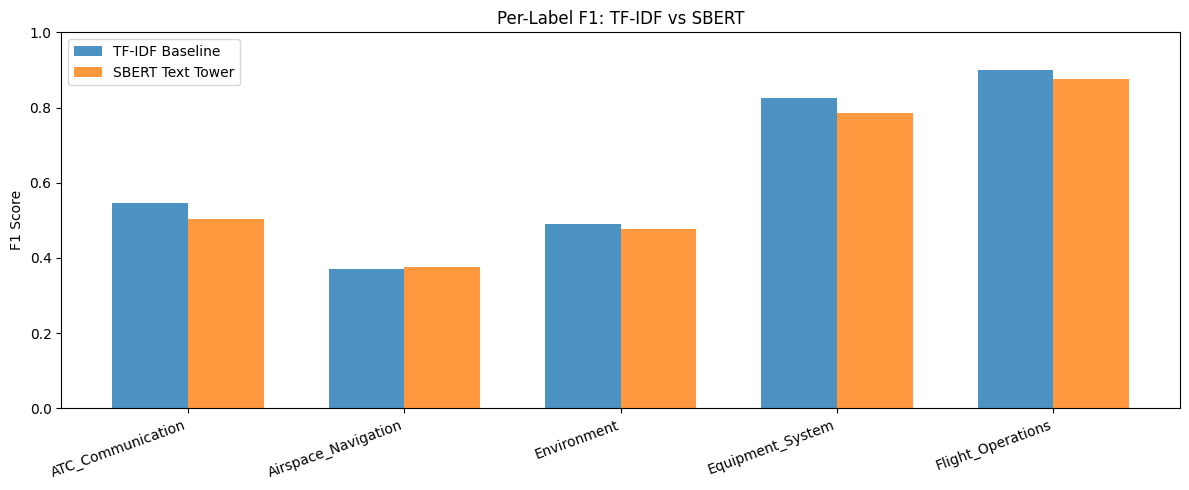

In [9]:
results = {'TF-IDF Baseline': t1_report, 'SBERT Text Tower': t2_report}
metrics = ['macro_f1', 'micro_f1', 'hamming_loss', 'subset_accuracy']
summary = pd.DataFrame({
    name: {m: r[m] for m in metrics}
    for name, r in results.items()
}).T
display(summary.round(4))

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(label_names))
width = 0.35
for i, (name, r) in enumerate(results.items()):
    f1s = [r['per_label'][l]['f1'] for l in label_names]
    ax.bar([xi + i * width for xi in x], f1s, width=width, label=name, alpha=0.8)
ax.set_xticks([xi + width/2 for xi in x])
ax.set_xticklabels(label_names, rotation=20, ha='right')
ax.set_ylabel('F1 Score')
ax.set_title('Per-Label F1: TF-IDF vs SBERT')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()